In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/mricardo89/data-mining/main/Unit-III/datasets/players_data-2025_2026.csv"

df = pd.read_csv(url)

df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,3,0,0,20,51,5,37,17,27,0
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,0,0,0,3,1,0,3,2,4,0
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,0,0,0,7,3,2,30,3,3,0
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,1,0,0,3,0,0,1,2,1,0


In [2]:
df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts',
       ...
       'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY', 'Fls', 'Fld', 'Off',
       'Crs', 'Int', 'TklW', 'OG'],
      dtype='object', length=102)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2839 entries, 0 to 2838
Columns: 102 entries, Rk to OG
dtypes: float64(45), int64(40), object(17)
memory usage: 2.2+ MB


In [5]:
features = ["Gls", "Ast", "Min", "Sh/90"]

data = df[["Player"] + features].copy()

data.head()

,Player,Gls,Ast,Min,Sh/90
0,Brenden Aaronson,4,5,2449,1.73
1,Jerome Abbey,0,0,17,0.00
2,Zach Abbott,0,0,164,0.00
3,Jones El-Abdellaoui,2,0,681,2.25
4,Himad Abdelli,0,0,138,2.61


In [6]:
data[features].dtypes

Gls        int64
Ast        int64
Min        int64
Sh/90    float64
dtype: object

In [7]:
data[features] = data[features].apply(pd.to_numeric, errors="coerce")

In [8]:
data = data.dropna()

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(data[features])

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=data.index
)

X_scaled.head()

,Gls,Ast,Min,Sh/90
0,0.797892,2.095652,1.277629,0.160260
1,-0.566285,-0.632501,-1.247683,-0.546419
2,-0.566285,-0.632501,-1.095043,-0.546419
3,0.115804,-0.632501,-0.558206,0.372673
4,-0.566285,-0.632501,-1.122040,0.519727


### Normalizacion

Antes de calcular las distancias tenemos que normalizar las variables. Esto es necesario porque cada caracteristica tiene una escala diferente. Por ejemplo, los minutos jugados tienen valores mucho mas grandes que los goles. Usamos StandardScaler para que ninguna variable tenga mas peso solo por tener valores mas grandes.

In [10]:
star_index = data["Gls"].idxmax()

star_player = data.loc[star_index, "Player"]

print("Jugador estrella:", star_player)

Jugador estrella: Harry Kane


In [11]:
star_vector = X_scaled.loc[star_index].values

print("Vector jugador estrella:")
print(star_vector)

Vector del jugador estrella:
[11.71130618  2.09565212  1.20286658  1.29584932]


In [12]:
distances_euclidean = np.linalg.norm(
    X_scaled.values - star_vector,
    axis=1
)

distances_euclidean

array([10.9725913 , 12.94531589, 12.91729066, ..., 12.9466938 ,
       12.67161145, 12.81842291], shape=(2839,))

In [13]:
distances_euclidean[star_index] = np.inf

euclidean_index = np.argmin(distances_euclidean)

euclidean_player = data.loc[euclidean_index, "Player"]

print("Reemplazo sugerido por distancia euclidiana:", euclidean_player)

Reemplazo sugerido por distancia Euclidiana: Erling Haaland


In [14]:
def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))

In [15]:
distances_manhattan = np.array([
    manhattan_distance(player, star_vector)
    for player in X_scaled.values
])

distances_manhattan

array([12.12376566, 19.29856195, 19.1459218 , ..., 19.30583053,
       17.41800275, 18.03842831], shape=(2839,))

In [16]:
distances_manhattan[star_index] = np.inf

manhattan_index = np.argmin(distances_manhattan)

manhattan_player = data.loc[manhattan_index, "Player"]

print("Reemplazo sugerido por distancia manhattan:", manhattan_player)

Reemplazo sugerido por distancia Manhattan: Kylian Mbappé


### Analisis critico

Los dos metodos no dieron el mismo jugador. La distancia Euclidiana sugirio a Erling Haaland, mientras que la distancia Manhattan sugirio a Kylian Mbappe.

Esto pasa porque cada distancia calcula la similitud de diferente manera. La Euclidiana da mas peso a las diferencias grandes, mientras que Manhattan suma las diferencias absolutas.

In [17]:
random_index = np.random.choice(
    data.index.difference([star_index, euclidean_index])
)

random_player = data.loc[random_index, "Player"]

print("Tercer jugador:", random_player)

Tercer jugador: Josha Vagnoman


In [18]:
players_indices = [star_index, euclidean_index, random_index]

players_names = [
    data.loc[star_index, "Player"],
    data.loc[euclidean_index, "Player"],
    data.loc[random_index, "Player"]
]

players_vectors = X_scaled.loc[players_indices]

players_vectors

,Gls,Ast,Min,Sh/90
1319,11.711306,2.095652,1.202867,1.295849
1104,8.641908,3.732544,1.800967,1.022164
2661,-0.225241,1.004391,0.382556,-0.105255


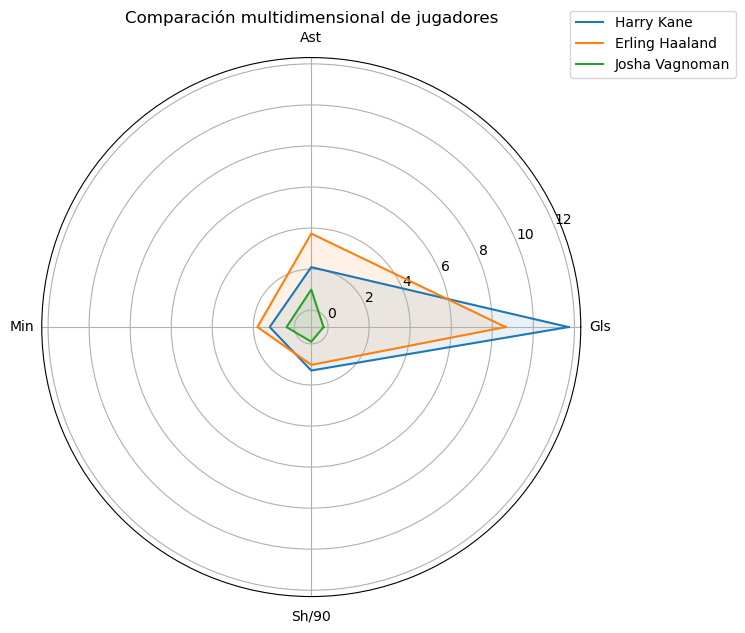

In [19]:
angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i in range(len(players_names)):
    values = players_vectors.iloc[i].tolist()
    values += values[:1]

    ax.plot(angles, values, label=players_names[i])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)

ax.set_title("Comparación multidimensional de jugadores")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()



### Interpretacion

El grafico permite comparar a Harry Kane, Erling Haaland y Josha Vagnoman usando las cuatro caracteristicas.

Como los datos fueron normalizados, podemos comparar las variables de una forma mas equilibrada. La grafica ayuda a observar visualmente las diferencias entre los perfiles.

### Conclusion

En esta actividad convertimos las caracteristicas de los jugadores en vectores multidimensionales. Normalizamos los datos y usamos las distancias euclidiana y manhattan para buscar jugadores similares a Harry Kane.

La euclidiana sugirio a Erling Haaland y la Manhattan a Kylian Mbappe. Esto demuestra que la metrica utilizada puede cambiar el resultado. Por ultimo usamos un radar chart para comparar visualmente los perfiles de los jugadores.